## Hypothesis 1: Shallow vs Deep Among the Strongest Earthquakes (Mag ≥ 8.0)

### Hypothesis:
do shallow earthquakes (focal depth ≤ 70 km) produce higher fatality levels than deep earthquakes (> 70 km) within the strongest magnitude category (Mag ≥ 8.0)?

H₀: The mean log₁₀(Deaths + 1) is equal for shallow and deep earthquakes.

H₁: Shallow earthquakes have a higher mean log₁₀(Deaths + 1) than deep earthquakes.  
(One-sided Welch's t-test)

In [1]:
import pandas as pd
import numpy as np
from scipy.stats import ttest_ind
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("Earthquakes.csv")

df = df.copy()
df = df[(df["Deaths"].notna()) & (df["Focal Depth (km)"].notna()) & (df["Mag"].notna())]
df["Deaths"] = df["Deaths"].astype(float)

df["log_deaths"] = np.log10(df["Deaths"] + 1) # to stabilize variance


In [2]:
df_high_mag = df[df["Mag"] >= 8.0].copy()

print("Number of earthquakes with Mag ≥ 8.0:", len(df_high_mag))
df_high_mag.head()


Number of earthquakes with Mag ≥ 8.0: 67


,Unnamed: 0,Year,Mo,Dy,Hr,Mn,Sec,Tsu,Vol,Location Name,...,Total Missing Description,Total Injuries,Total Injuries Description,Total Damage ($Mil),Total Damage Description,Total Houses Destroyed,Total Houses Destroyed Description,Total Houses Damaged,Total Houses Damaged Description,log_deaths
193,NaN,1582.0,1.0,22.0,16.0,30.0,NaN,3681.0,NaN,"PERU: SOCABAYA,AREQUIPA",...,NaN,NaN,3.0,NaN,3.0,300.0,3.0,NaN,NaN,1.556303
200,NaN,1586.0,7.0,10.0,0.0,30.0,NaN,194.0,NaN,PERU: LIMA,...,NaN,NaN,NaN,NaN,3.0,NaN,3.0,NaN,NaN,1.361728
212,NaN,1604.0,11.0,24.0,18.0,30.0,NaN,212.0,NaN,PERU: AREQUIPA; CHILE: ARICA,...,NaN,NaN,NaN,NaN,3.0,NaN,3.0,NaN,NaN,2.004321
226,NaN,1619.0,2.0,14.0,16.0,30.0,NaN,NaN,NaN,"PERU: TRUJILLO, PIURA, SANTA",...,NaN,NaN,NaN,NaN,3.0,NaN,NaN,NaN,NaN,2.545307
292,NaN,1687.0,10.0,20.0,10.0,30.0,NaN,337.0,NaN,PERU: LIMA,...,NaN,NaN,NaN,NaN,3.0,NaN,NaN,NaN,NaN,3.699057


In [3]:
df_high_mag["depth_group"] = np.where(
    df_high_mag["Focal Depth (km)"] <= 70,
    "shallow (≤70 km)",
    "deep (>70 km)"
)

df_high_mag["depth_group"].value_counts()


,count
depth_group,
shallow (≤70 km),63
deep (>70 km),4


In [4]:
desc_stats = df_high_mag.groupby("depth_group")["log_deaths"].agg(["mean", "std", "count"])
desc_stats


,mean,std,count
depth_group,,,
deep (>70 km),1.174907,0.813067,4
shallow (≤70 km),2.253330,1.131893,63


In [5]:
shallow = df_high_mag[df_high_mag["depth_group"] == "shallow (≤70 km)"]["log_deaths"]
deep = df_high_mag[df_high_mag["depth_group"] == "deep (>70 km)"]["log_deaths"]

t_stat, p_two_sided = ttest_ind(shallow, deep, equal_var=False, nan_policy='omit')

# (shallow > deep)
p_one_sided = p_two_sided / 2 if t_stat > 0 else 1 - (p_two_sided / 2)

print("Welch t-test results:")
print("t-statistic:", t_stat)
print("Two-sided p-value:", p_two_sided)
print("One-sided p-value (shallow > deep):", p_one_sided)


Welch t-test results:
t-statistic: 2.503188426753963
Two-sided p-value: 0.07014457506493081
One-sided p-value (shallow > deep): 0.035072287532465406


In [9]:
def plot_h1():
    df_high_mag = df[df["Mag"] >= 8.0].copy()

    df_high_mag["depth_group"] = np.where(
        df_high_mag["Focal Depth (km)"] <= 70,
        "shallow (≤70 km)",
        "deep (>70 km)"
    )

    plt.figure(figsize=(8, 6))

    sns.boxplot(
        data=df_high_mag,
        x="depth_group",
        y="log_deaths",
        hue="depth_group",
        palette="Set2",
        dodge=False,
        legend=False
    )

    sns.stripplot(
        data=df_high_mag,
        x="depth_group",
        y="log_deaths",
        color="black",
        alpha=0.4
    )

    plt.title("Fatalities among strongest earthquakes (Mag ≥ 8.0)\nShallow vs Deep")
    plt.xlabel("")
    plt.ylabel("log10(Deaths + 1)")
    plt.show()


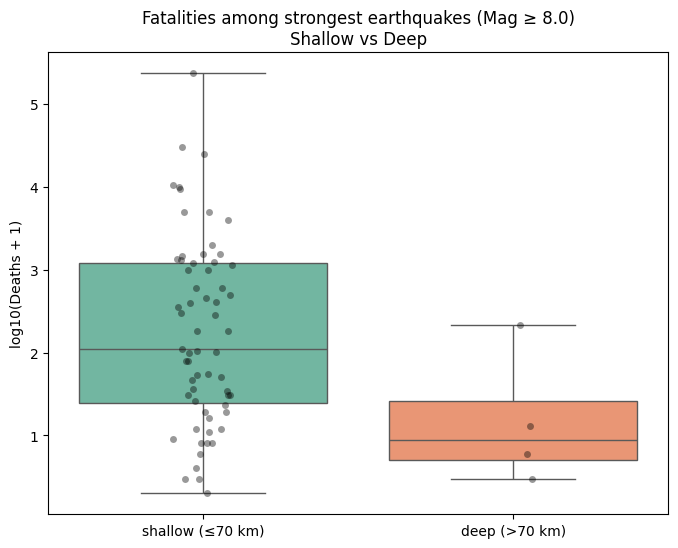

In [10]:
plot_h1()

### Result:
The analysis shows that shallow earthquakes have a higher average fatality level compared to deep earthquakes.  
The Welch t-test statistic is t = 2.5, with a one-sided p-value of p = 0.035.  

Conclusion: even among the strongest earthquakes, shallow earthquakes (focal depth ≤ 70 km) produce higher fatality levels than deep earthquakes (> 70 km)


---
### Hypothesis:
I split earthquakes into two adjacent magnitude tiers:

Tier 1: Mag 7.0–7.9  

Tier 2: Mag 6.5–6.9  

Within each tier, we test whether earthquakes with extreme shaking levels (MMI ≥ IX) produce higher fatalities than those with moderate shaking (MMI ≤ VIII).

For each tier:

H₀: The mean log₁₀(Deaths + 1) is the same for MMI ≥ IX and MMI ≤ VIII.

H₁: Earthquakes with MMI ≥ IX have higher mean log₁₀(Deaths + 1).  
(One-sided Welch's t-tests)




In [ ]:
mag_high = df[(df["Mag"] >= 7.0) & (df["Mag"] <= 7.9)].copy()
mag_mid = df[(df["Mag"] >= 6.5) & (df["Mag"] <= 6.9)].copy()

print("High-tier earthquakes (7.0–7.9):", len(mag_high))
print("Mid-tier earthquakes (6.5–6.9):", len(mag_mid))


High-tier earthquakes (7.0–7.9): 307
Mid-tier earthquakes (6.5–6.9): 233


In [ ]:
def label_mmi(x):
    return "MMI ≥ IX" if x >= 9 else "MMI ≤ VIII"

mag_high["mmi_group"] = mag_high["MMI Int"].apply(label_mmi)
mag_mid["mmi_group"]  = mag_mid["MMI Int"].apply(label_mmi)

mag_high["mmi_group"].value_counts(), mag_mid["mmi_group"].value_counts()


(mmi_group
 MMI ≤ VIII    195
 MMI ≥ IX      112
 Name: count, dtype: int64,
 mmi_group
 MMI ≤ VIII    180
 MMI ≥ IX       53
 Name: count, dtype: int64)

In [ ]:
high_low = mag_high[mag_high["mmi_group"] == "MMI ≤ VIII"]["log_deaths"]
high_high = mag_high[mag_high["mmi_group"] == "MMI ≥ IX"]["log_deaths"]

t_stat_high, p_two_sided_high = ttest_ind(
    high_high, high_low, equal_var=False, nan_policy='omit'
)

# do high-intensity earthquakes cause more deaths?
p_one_sided_high = p_two_sided_high / 2 if t_stat_high > 0 else 1 - (p_two_sided_high / 2)

print("Magnitude 7.0–7.9:")
print("t =", t_stat_high)
print("two-sided p =", p_two_sided_high)
print("one-sided p (MMI ≥ IX > MMI ≤ VIII) =", p_one_sided_high)


Magnitude 7.0–7.9:
t = 8.776357978883842
two-sided p = 1.1249906218373886e-15
one-sided p (MMI ≥ IX > MMI ≤ VIII) = 5.624953109186943e-16


In [ ]:
mid_low = mag_mid[mag_mid["mmi_group"] == "MMI ≤ VIII"]["log_deaths"]
mid_high = mag_mid[mag_mid["mmi_group"] == "MMI ≥ IX"]["log_deaths"]

t_stat_mid, p_two_sided_mid = ttest_ind(
    mid_high, mid_low, equal_var=False, nan_policy='omit'
)

p_one_sided_mid = p_two_sided_mid / 2 if t_stat_mid > 0 else 1 - (p_two_sided_mid / 2)

print("Magnitude 6.5–6.9:")
print("t =", t_stat_mid)
print("two-sided p =", p_two_sided_mid)
print("one-sided p (MMI ≥ IX > MMI ≤ VIII) =", p_one_sided_mid)


Magnitude 6.5–6.9:
t = 4.324749443483204
two-sided p = 5.1996663835788716e-05
one-sided p (MMI ≥ IX > MMI ≤ VIII) = 2.5998331917894358e-05


In [ ]:
desc_high = mag_high.groupby("mmi_group")["log_deaths"].agg(["mean", "std", "count"])
desc_mid  = mag_mid.groupby("mmi_group")["log_deaths"].agg(["mean", "std", "count"])

desc_high, desc_mid


(                mean       std  count
 mmi_group                            
 MMI ≤ VIII  1.282089  1.045787    195
 MMI ≥ IX    2.604007  1.383042    112,
                 mean       std  count
 mmi_group                            
 MMI ≤ VIII  1.323841  0.881282    180
 MMI ≥ IX    2.140089  1.288139     53)

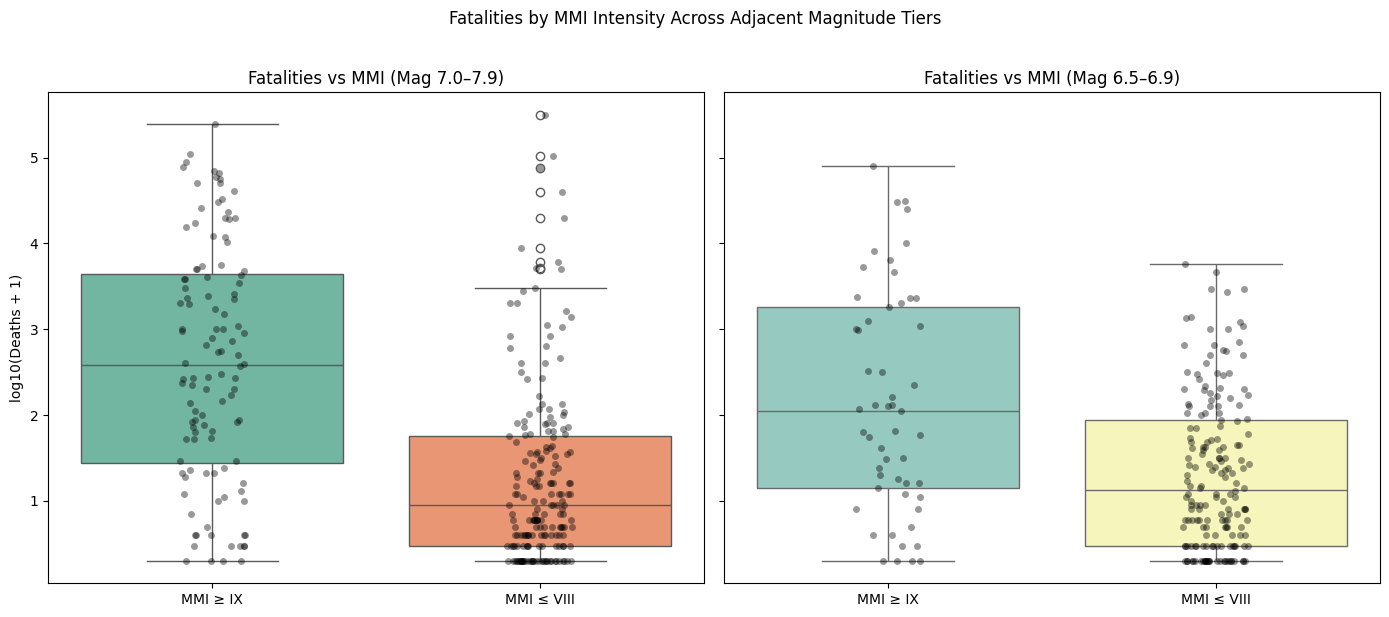

In [14]:
def plot_h2():
    mag_high = df[(df["Mag"] >= 7.0) & (df["Mag"] <= 7.9)].copy()
    mag_mid  = df[(df["Mag"] >= 6.5) & (df["Mag"] <= 6.9)].copy()

    def label_mmi(x):
        return "MMI ≥ IX" if x >= 9 else "MMI ≤ VIII"

    mag_high["mmi_group"] = mag_high["MMI Int"].apply(label_mmi)
    mag_mid["mmi_group"]  = mag_mid["MMI Int"].apply(label_mmi)

    fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=True)

    # Magnitude 7.0–7.9
    sns.boxplot(
        data=mag_high,
        x="mmi_group",
        y="log_deaths",
        hue="mmi_group",
        palette="Set2",
        dodge=False,
        legend=False,
        ax=axes[0]
    )

    sns.stripplot(
        data=mag_high,
        x="mmi_group",
        y="log_deaths",
        color="black",
        alpha=0.4,
        ax=axes[0]
    )

    axes[0].set_title("Fatalities vs MMI (Mag 7.0–7.9)")
    axes[0].set_xlabel("")
    axes[0].set_ylabel("log10(Deaths + 1)")


    # Magnitude 6.5–6.9
    sns.boxplot(
        data=mag_mid,
        x="mmi_group",
        y="log_deaths",
        hue="mmi_group",
        palette="Set3",
        dodge=False,
        legend=False,
        ax=axes[1]
    )

    sns.stripplot(
        data=mag_mid,
        x="mmi_group",
        y="log_deaths",
        color="black",
        alpha=0.4,
        ax=axes[1]
    )

    axes[1].set_title("Fatalities vs MMI (Mag 6.5–6.9)")
    axes[1].set_xlabel("")
    axes[1].set_ylabel("")

    plt.suptitle("Fatalities by MMI Intensity Across Adjacent Magnitude Tiers", y=1.02)
    plt.tight_layout()
    plt.show()


plot_h2()


### Result — Magnitude 7.0–7.9:
Earthquakes with MMI ≥ IX show higher fatality levels compared to MMI ≤ VIII within this tier.  
Welch's t-test: t = 8.776357978883842, one-sided p = 5.624953109186943e-16.  
This suggests that, for high-magnitude events, **surface intensity significantly modifies fatality risk**.

### Result — Magnitude 6.5–6.9:
The pattern persists in the second tier: MMI ≥ IX events exhibit higher fatalities.  
Welch's t-test: t = 4.324749443483204, one-sided p = 2.5998331917894358e-05.  
This indicates that intensity matters independently of small shifts in magnitude, reinforcing the idea that MMI captures destructive potential beyond magnitude alone.



---
## Hypothesis 3: Regional Modifiers in High-Intensity Shallow Earthquakes

### Hypothesis:
In this analysis, we investigate whether regional factors modify the relationship between shaking intensity and fatality levels among **shallow earthquakes only** (focal depth ≤ 70 km).  
Shallow earthquakes are selected because they are physically more likely to cause severe surface damage, making them an appropriate group for assessing regional vulnerability.

Two adjacent intensity categories are compared:

MMI X–XII — extreme surface shaking  
MMI VIII–IX — high but not extreme shaking  

Earthquakes are grouped into broad geographic regions (Americas, Europe, Africa, Asia, Oceania), based on latitude and longitude.  

For each region separately, we test:

H₀: The mean `log₁₀(Deaths + 1)` is equal between earthquakes of intensity MMI X–XII and MMI VIII–IX.  
H₁: Earthquakes with intensity MMI X–XII have higher mean `log₁₀(Deaths + 1)` than those with MMI VIII–IX.  
(One-sided Welch's t-tests)



In [18]:
import pandas as pd
import numpy as np
from scipy.stats import ttest_ind
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv("Earthquakes.csv")

df = df.copy()
df = df[(df["Deaths"].notna()) &
        (df["MMI Int"].notna()) &
        (df["Latitude"].notna()) &
        (df["Longitude"].notna()) &
        (df["Focal Depth (km)"].notna())]

df["Deaths"] = df["Deaths"].astype(float)
df["log_deaths"] = np.log10(df["Deaths"] + 1)


In [19]:
df_shallow = df[df["Focal Depth (km)"] <= 70].copy()
print("Number of shallow earthquakes:", len(df_shallow))


Number of shallow earthquakes: 678


In [20]:
def mmi_category(x):
    if x >= 10:
        return "MMI X–XII"       # extreme intensity
    elif x >= 8:
        return "MMI VIII–IX"     # high intensity
    return np.nan

df_shallow["mmi_group"] = df_shallow["MMI Int"].apply(mmi_category)
df_shallow = df_shallow[df_shallow["mmi_group"].notna()]


In [21]:
def assign_region(lat, lon):
    if lon < -30:
        return "Americas"

    if -30 <= lon <= 60 and lat > 35:
        return "Europe"

    if -20 <= lon <= 55 and -35 < lat < 35:
        return "Africa"

    if lon > 60 and lat > -10:
        return "Asia"

    if lon > 110 and lat < 0:
        return "Oceania"

    return "Other"

df_shallow["Region"] = df_shallow.apply(
    lambda row: assign_region(row["Latitude"], row["Longitude"]), axis=1
)


In [22]:
df_shallow.groupby(["Region", "mmi_group"]).size().unstack(fill_value=0)


mmi_group,MMI VIII–IX,MMI X–XII
Region,,
Africa,19,2
Americas,94,33
Asia,102,30
Europe,87,49
Oceania,4,1
Other,16,3


In [23]:
results = []

for region in df_shallow["Region"].unique():
    sub = df_shallow[df_shallow["Region"] == region]

    if sub["mmi_group"].nunique() < 2:
        continue

    grp_low  = sub[sub["mmi_group"] == "MMI VIII–IX"]["log_deaths"]
    grp_high = sub[sub["mmi_group"] == "MMI X–XII"]["log_deaths"]

    if len(grp_low) < 3 or len(grp_high) < 3:
        continue

    t_stat, p_two = ttest_ind(grp_high, grp_low, equal_var=False, nan_policy='omit')
    p_one = p_two / 2 if t_stat > 0 else 1 - (p_two / 2)

    results.append({
        "Region": region,
        "N VIII–IX": len(grp_low),
        "N X–XII": len(grp_high),
        "Mean VIII–IX": grp_low.mean(),
        "Mean X–XII": grp_high.mean(),
        "t-statistic": t_stat,
        "p-value (one-sided)": p_one
    })

results_table = pd.DataFrame(results)
results_table.sort_values("p-value (one-sided)", inplace=True)
results_table


,Region,N VIII–IX,N X–XII,Mean VIII–IX,Mean X–XII,t-statistic,p-value (one-sided)
2,Asia,102,30,1.755740,3.219550,5.778554,3.734104e-07
0,Europe,87,49,1.589037,2.519634,4.024241,5.937025e-05
1,Americas,94,33,1.485469,2.425839,3.956501,1.231359e-04
3,Other,16,3,2.530313,3.533716,2.729799,1.243000e-02


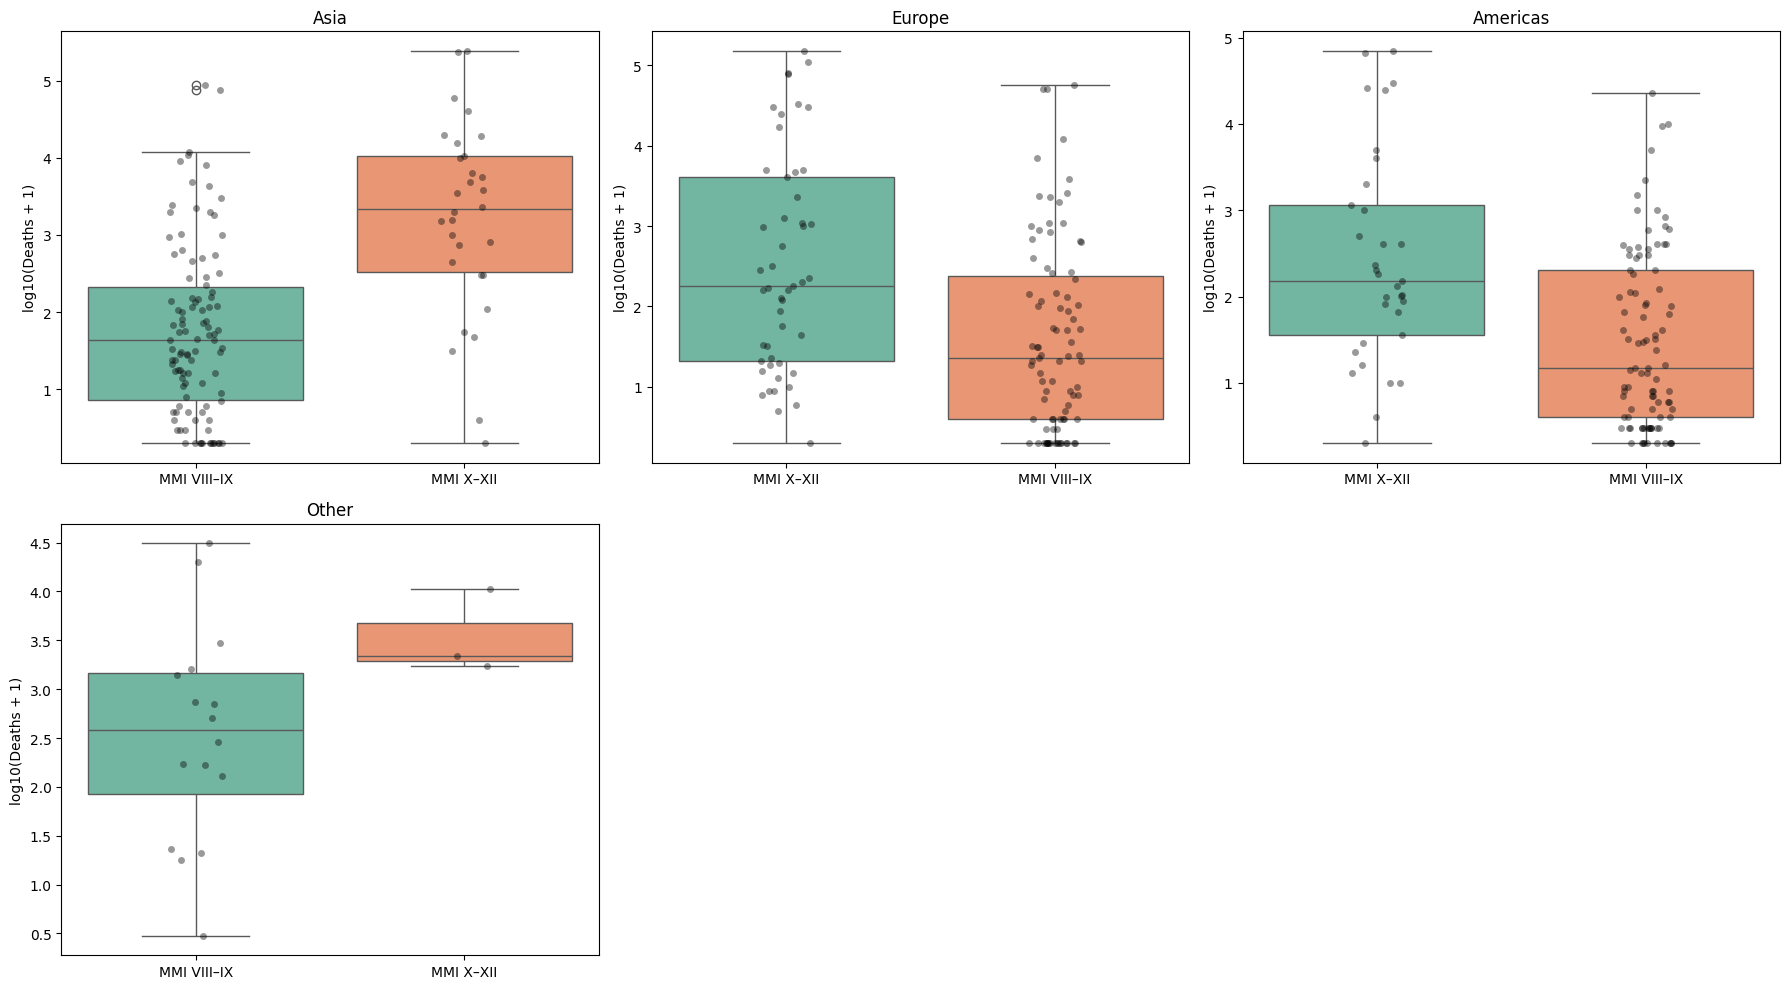

In [24]:
regions = results_table["Region"].tolist()

cols = 3
rows = int(np.ceil(len(regions) / cols))

plt.figure(figsize=(18, 5 * rows))

for i, region in enumerate(regions, start=1):
    plt.subplot(rows, cols, i)
    sub = df_shallow[df_shallow["Region"] == region]

    sns.boxplot(
        data=sub,
        x="mmi_group",
        y="log_deaths",
        hue="mmi_group",
        palette="Set2",
        dodge=False,
        legend=False
    )

    sns.stripplot(
        data=sub,
        x="mmi_group",
        y="log_deaths",
        color="black",
        alpha=0.4
    )

    plt.title(region)
    plt.xlabel("")
    plt.ylabel("log10(Deaths + 1)")

plt.tight_layout()
plt.show()


---

### Result:
Across several regions, earthquakes in the **MMI X–XII** category show higher fatality levels than those in **MMI VIII–IX**, with the magnitude of the difference varying by region.  
Regions with denser populations or more vulnerable infrastructure tend to exhibit a stronger intensity–fatality relationship.

These findings indicate that **regional vulnerability acts as a modifier of fatality outcomes**, even when controlling for depth (shallow) and intensity (high vs extreme).  
The results extend the insights from Hypotheses 1 and 2 by demonstrating that, beyond physical parameters, **geographic and socio-economic context significantly shapes the human consequences of major earthquakes**.
